In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [2]:
pd.set_option("display.max_columns", None)
df = pd.read_csv(r"C:\DATA_SCIENCE\Final_Projects\Capstone\Loan_approval_data_2025.csv")
df

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40.0,Employed,17.2,25579.0,692,5.3,895,10820,No,0,0,Credit Card,Business,600,17.02,NaN,0.023,0.008,Approved
1,CUST100001,33.0,Employed,7.3,43087.0,627,3.5,169,16550,No,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,Rejected
2,CUST100002,42.0,Student,1.1,20840.0,689,8.4,17,7852,No,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,NaN,0.034,Approved
3,CUST100003,53.0,Student,0.5,29147.0,692,9.8,1480,11603,No,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,Approved
4,CUST100004,32.0,Employed,12.5,NaN,630,7.2,209,12424,No,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,Approved
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35.0,Employed,4.3,39449.0,570,16.3,1127,7576,No,0,0,Credit Card,Education,42800,21.31,0.192,1.085,0.362,Rejected
49996,CUST149996,34.0,Employed,4.4,20496.0,672,12.6,1478,6276,Yes,0,0,Credit Card,Personal,3800,18.07,0.306,0.185,0.062,Rejected
49997,CUST149997,41.0,Self-Employed,4.8,18743.0,719,10.1,17,10331,No,0,0,Credit Card,Personal,18000,17.45,0.551,0.960,0.320,Rejected
49998,CUST149998,38.0,Student,0.4,17250.0,633,1.3,5,7779,No,0,1,Personal Loan,Personal,1400,14.71,0.451,0.081,0.027,Rejected


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      49980 non-null  float64
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            49993 non-null  float64
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  object 
 10  delinquencies_last_2yrs  50000 non-null  object 
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [4]:
df.isnull().sum()

customer_id                  0
age                         20
occupation_status            0
years_employed               0
annual_income                7
credit_score                 0
credit_history_years         0
savings_assets               0
current_debt                 0
defaults_on_file             0
delinquencies_last_2yrs      0
derogatory_marks             0
product_type                 0
loan_intent                  0
loan_amount                  0
interest_rate                0
debt_to_income_ratio       269
loan_to_income_ratio        37
payment_to_income_ratio      0
loan_status                  0
dtype: int64

In [5]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio
count,49980.000000,50000.000000,49993.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49731.000000,49963.000000,50000.000000
mean,34.958904,7.454868,50060.913248,643.614820,8.168274,3595.619400,14290.442220,0.147640,33041.874000,15.498591,0.285695,0.702200,0.233995
std,11.120110,7.612097,32632.252232,64.731518,7.207552,13232.399398,13243.757493,0.412996,26116.185102,4.067942,0.159814,0.465784,0.155268
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000
25%,26.000000,1.300000,27277.000000,600.000000,2.000000,130.000000,5581.000000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000
50%,35.000000,4.900000,41605.000000,643.000000,6.100000,568.000000,10385.000000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000
75%,43.000000,11.400000,62714.000000,687.000000,12.600000,2271.000000,18449.250000,0.000000,48500.000000,18.870000,0.389000,1.011000,0.337000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000


In [7]:
data = df.copy()

# Handle Missing Value

## age

In [8]:
df["age"].isnull().sum()

np.int64(20)

In [9]:
df[df["age"].isnull()]

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
11,CUST100011,NaN,Student,1.3,17029.0,668,4.3,215,5592,No,0,0,Line of Credit,Personal,6300,9.69,0.328,0.370,0.123,Approved
126,CUST100126,NaN,Student,0.1,15000.0,617,2.7,79,716,No,1,0,Credit Card,Education,1500,20.97,0.048,0.100,0.033,Approved
152,CUST100152,NaN,Student,0.2,16409.0,653,7.5,550,4709,No,0,0,Personal Loan,Personal,5900,11.80,0.287,0.360,0.120,Approved
12290,CUST112290,NaN,Student,0.7,15000.0,638,6.8,427,559,No,0,0,Personal Loan,Education,9600,13.22,0.037,0.640,0.213,Approved
12671,CUST112671,NaN,Student,0.5,25042.0,630,9.1,1409,3138,No,1,0,Personal Loan,Medical,11900,13.76,0.125,0.475,0.158,Approved
12712,CUST112712,NaN,Student,0.6,19033.0,664,3.6,45,10736,No,1,0,Credit Card,Education,1900,18.69,0.564,0.100,0.033,Rejected
12768,CUST112768,NaN,Student,0.1,17072.0,591,10.8,2381,8986,No,0,0,Line of Credit,Education,11200,14.44,0.526,0.656,0.219,Rejected
12842,CUST112842,NaN,Student,1.2,18710.0,622,16.5,2943,5051,No,1,0,Personal Loan,Personal,12100,14.85,0.270,0.647,0.216,Approved
13268,CUST113268,NaN,Student,0.9,17728.0,606,0.1,1,7636,No,0,0,Credit Card,Personal,1800,20.22,0.431,0.102,0.034,Approved
13520,CUST113520,NaN,Student,1.8,48025.0,696,8.2,639,4904,No,0,0,Line of Credit,Personal,31600,10.69,0.102,0.658,0.219,Approved


In [10]:
# find the avg age of student and fill the na age with that value

avg_age_student = int(data[data["occupation_status"] == "Student"]["age"].mean())
data["age"] = df["age"].fillna(avg_age_student)
data["age"].isnull().sum()

np.int64(0)

## annual_income

In [11]:
# fill with mean value

mean_income_val = int(data["annual_income"].mean())
data["annual_income"] = data["annual_income"].fillna(mean_income_val)
data["annual_income"].isnull().sum()

np.int64(0)

## delinquencies_last_2yrs

In [12]:
print(data["delinquencies_last_2yrs"].value_counts())
print("\nData type: ",data["delinquencies_last_2yrs"].dtype)

delinquencies_last_2yrs
0     30792
1     13043
2      4399
3      1280
4       384
5        77
6        13
No        5
7         5
8         1
9         1
Name: count, dtype: int64

Data type:  object


In [13]:
# replace "no" with 0, becouse no = 0, Then convert data type into int

data["delinquencies_last_2yrs"] = data["delinquencies_last_2yrs"].replace({"No" : 0})
data["delinquencies_last_2yrs"] = data["delinquencies_last_2yrs"].astype("int")

print(data["delinquencies_last_2yrs"].value_counts())
print("\nData type: ",data["delinquencies_last_2yrs"].dtype)

delinquencies_last_2yrs
0    30797
1    13043
2     4399
3     1280
4      384
5       77
6       13
7        5
8        1
9        1
Name: count, dtype: int64

Data type:  int64


## product_type

In [14]:
data["product_type"].value_counts()

product_type
Credit Card       22455
Personal Loan     17520
Line of Credit    10022
Personal  Loan        3
Name: count, dtype: int64

In [15]:
# remove extra space from Personal  Loan 

data["product_type"] = data["product_type"].replace("Personal  Loan", "Personal Loan")
data["product_type"].value_counts()

product_type
Credit Card       22455
Personal Loan     17523
Line of Credit    10022
Name: count, dtype: int64

## loan_intent              

In [16]:
data["loan_intent"].value_counts()

loan_intent
Personal              12429
Education             10129
Medical                7593
Business               7460
Home Improvement       7453
Debt Consolidation     4917
BUSINESS                  8
Study                     5
Health                    5
 Business                 1
Name: count, dtype: int64

In [17]:
# Education and Study both same
# Medical and Health both same
# covert BUSINESS into Business
# removeextra space from  Business

data["loan_intent"] = data["loan_intent"].replace({"Study" : "Education", "Health" : "Medical", "BUSINESS" : "Business", " Business" : "Business"})
data["loan_intent"].value_counts()

loan_intent
Personal              12429
Education             10134
Medical                7598
Business               7469
Home Improvement       7453
Debt Consolidation     4917
Name: count, dtype: int64

## debt_to_income_ratio

In [18]:
## formula current_debt/annual_income, fill na using this formula


data["debt_to_income_ratio"] = data["debt_to_income_ratio"].fillna(data["current_debt"]/data["annual_income"])
data["debt_to_income_ratio"].isnull().sum()

np.int64(0)

## loan_to_income_ratio

In [19]:
## formula loan_amount/annual_income, fill na using this formula


data["loan_to_income_ratio"] = data["loan_to_income_ratio"].fillna(data["loan_amount"]/data["annual_income"])
data["loan_to_income_ratio"].isnull().sum()

np.int64(0)

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  float64
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  float64
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  object 
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

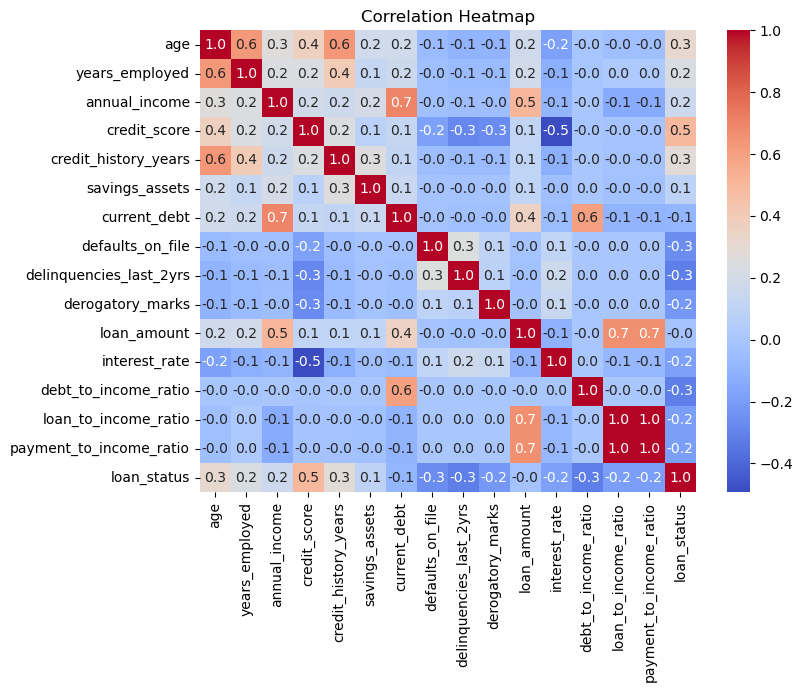

In [21]:
# Heat map to find relation btn features

data_plot = data.copy()
data_plot['loan_status'] = data_plot['loan_status'].map({'Approved': 1, 'Rejected': 0})
data_plot['defaults_on_file'] = data_plot['defaults_on_file'].map({'Yes': 1, 'No': 0})
numeric_data = data_plot.select_dtypes(include=['int64', 'float64'])
corr = numeric_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()

# Encoding

In [22]:
data.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40.0,Employed,17.2,25579.0,692,5.3,895,10820,No,0,0,Credit Card,Business,600,17.02,0.423003,0.023000,0.008,Approved
1,CUST100001,33.0,Employed,7.3,43087.0,627,3.5,169,16550,No,1,0,Personal Loan,Home Improvement,53300,14.10,0.384000,1.237000,0.412,Rejected
2,CUST100002,42.0,Student,1.1,20840.0,689,8.4,17,7852,No,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377000,0.100768,0.034,Approved
3,CUST100003,53.0,Student,0.5,29147.0,692,9.8,1480,11603,No,1,0,Credit Card,Business,2900,18.74,0.398000,0.099000,0.033,Approved
4,CUST100004,32.0,Employed,12.5,50060.0,630,7.2,209,12424,No,0,0,Personal Loan,Education,99600,13.92,0.195000,1.565000,0.522,Approved


In [23]:
df_model = pd.get_dummies(data, columns=['occupation_status','product_type','loan_intent'], drop_first = True)
df_model["defaults_on_file"] = df_model["defaults_on_file"].replace({"No" : 0, "Yes" : 1})
df_model

,customer_id,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status,occupation_status_Self-Employed,occupation_status_Student,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal
0,CUST100000,40.0,17.2,25579.0,692,5.3,895,10820,0,0,0,600,17.02,0.423003,0.023000,0.008,Approved,False,False,False,False,False,False,False,False,False
1,CUST100001,33.0,7.3,43087.0,627,3.5,169,16550,0,1,0,53300,14.10,0.384000,1.237000,0.412,Rejected,False,False,False,True,False,False,True,False,False
2,CUST100002,42.0,1.1,20840.0,689,8.4,17,7852,0,0,0,2100,18.33,0.377000,0.100768,0.034,Approved,False,True,False,False,True,False,False,False,False
3,CUST100003,53.0,0.5,29147.0,692,9.8,1480,11603,0,1,0,2900,18.74,0.398000,0.099000,0.033,Approved,False,True,False,False,False,False,False,False,False
4,CUST100004,32.0,12.5,50060.0,630,7.2,209,12424,0,0,0,99600,13.92,0.195000,1.565000,0.522,Approved,False,False,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST149995,35.0,4.3,39449.0,570,16.3,1127,7576,0,0,0,42800,21.31,0.192000,1.085000,0.362,Rejected,False,False,False,False,False,True,False,False,False
49996,CUST149996,34.0,4.4,20496.0,672,12.6,1478,6276,1,0,0,3800,18.07,0.306000,0.185000,0.062,Rejected,False,False,False,False,False,False,False,False,True
49997,CUST149997,41.0,4.8,18743.0,719,10.1,17,10331,0,0,0,18000,17.45,0.551000,0.960000,0.320,Rejected,True,False,False,False,False,False,False,False,True
49998,CUST149998,38.0,0.4,17250.0,633,1.3,5,7779,0,0,1,1400,14.71,0.451000,0.081000,0.027,Rejected,False,True,False,True,False,False,False,False,True


# ML Model

In [24]:
x = df_model.drop(["customer_id", "loan_status"], axis = 1)
y = df_model["loan_status"]

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
print(f"Shape of x_train :",x_train.shape)
print(f"Shape of x_test :",x_test.shape)

Shape of x_train : (40000, 24)
Shape of x_test : (10000, 24)


## LogisticRegression

In [27]:
lr_model = LogisticRegression()
lr_model.fit(x_train, y_train)
y_pred = lr_model.predict(x_test)

lr_acc_score = accuracy_score(y_test, y_pred)
lr_conf_matrics = confusion_matrix(y_test, y_pred)
lr_clss_rep = classification_report(y_test,y_pred)

print("Accuracy score is :", lr_acc_score*100)
print("\nConfusion matrics is: \n", lr_conf_matrics)
print('\nSummary of the model performance :\n',lr_clss_rep)

# predicting new value
new = lr_model.predict([x.iloc[0].values])
new

Accuracy score is : 72.97

Confusion matrics is: 
 [[4409 1082]
 [1621 2888]]

Summary of the model performance :
               precision    recall  f1-score   support

    Approved       0.73      0.80      0.77      5491
    Rejected       0.73      0.64      0.68      4509

    accuracy                           0.73     10000
   macro avg       0.73      0.72      0.72     10000
weighted avg       0.73      0.73      0.73     10000



array(['Approved'], dtype=object)

##  DecisionTreeClassifier

In [28]:
dt_model = DecisionTreeClassifier()
dt_model.fit(x_train, y_train)
y_pred = dt_model.predict(x_test)

dt_acc_score = accuracy_score(y_test, y_pred)
dt_conf_matrics = confusion_matrix(y_test, y_pred)
dt_clss_rep = classification_report(y_test,y_pred)

print("Accuracy score is :", dt_acc_score*100)
print("\nConfusion matrics is: \n", dt_conf_matrics)
print('\nSummary of the model performance :\n',dt_clss_rep)

new = dt_model.predict([x.iloc[0].values])
new

Accuracy score is : 87.33

Confusion matrics is: 
 [[4838  653]
 [ 614 3895]]

Summary of the model performance :
               precision    recall  f1-score   support

    Approved       0.89      0.88      0.88      5491
    Rejected       0.86      0.86      0.86      4509

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



array(['Approved'], dtype=object)

## RandomForestClassifier

In [29]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_model.fit(x_train, y_train)
y_pred = rf_model.predict(x_test)

rf_acc_score = accuracy_score(y_test, y_pred)
rf_conf_matrics = confusion_matrix(y_test, y_pred)
rf_clss_rep = classification_report(y_test,y_pred)

print("Accuracy score is :", rf_acc_score*100)
print("\nConfusion matrics is: \n", rf_conf_matrics)
print('\nSummary of the model performance :\n',rf_clss_rep)

new = rf_model.predict([x.iloc[0].values])
new


Accuracy score is : 91.49000000000001

Confusion matrics is: 
 [[5106  385]
 [ 466 4043]]

Summary of the model performance :
               precision    recall  f1-score   support

    Approved       0.92      0.93      0.92      5491
    Rejected       0.91      0.90      0.90      4509

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



array(['Approved'], dtype=object)

## KNeighborsClassifier

In [30]:
x_scaled = ss.fit_transform(x)
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size = 0.2, random_state = 42)

knn_model = KNeighborsClassifier(n_neighbors = 5)  
knn_model.fit(x_train, y_train)
y_pred = knn_model.predict(x_test)

knn_acc_score = accuracy_score(y_test, y_pred)
knn_conf_matrics = confusion_matrix(y_test, y_pred)
conf_matrics = confusion_matrix(y_test, y_pred)
knn_clss_rep = classification_report(y_test,y_pred)

print("Accuracy score is :", knn_acc_score*100)
print("\nConfusion matrics is: \n", knn_conf_matrics)
print('\nSummary of the model performance :\n',knn_clss_rep)

new = knn_model.predict([x.iloc[0].values])
new

Accuracy score is : 85.87

Confusion matrics is: 
 [[4987  504]
 [ 909 3600]]

Summary of the model performance :
               precision    recall  f1-score   support

    Approved       0.85      0.91      0.88      5491
    Rejected       0.88      0.80      0.84      4509

    accuracy                           0.86     10000
   macro avg       0.86      0.85      0.86     10000
weighted avg       0.86      0.86      0.86     10000



array(['Rejected'], dtype=object)

## SVC

In [31]:
svc_model = SVC(kernel = 'poly', class_weight = "balanced")
svc_model.fit(x_train, y_train)
y_pred = svc_model.predict(x_test)

svc_acc_score = accuracy_score(y_test, y_pred)
svc_conf_matrics = confusion_matrix(y_test, y_pred)
svc_clss_rep = classification_report(y_test,y_pred)

print("Accuracy score is :", svc_acc_score*100)
print("\nConfusion matrics is: \n", svc_conf_matrics)
print('\nSummary of the model performance :\n',svc_clss_rep)

new = svc_model.predict([x.iloc[0].values])
new

Accuracy score is : 89.8

Confusion matrics is: 
 [[4970  521]
 [ 499 4010]]

Summary of the model performance :
               precision    recall  f1-score   support

    Approved       0.91      0.91      0.91      5491
    Rejected       0.89      0.89      0.89      4509

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



array(['Approved'], dtype=object)

In [ ]:
# data.to_csv("Loan_approval_data_2025(cleaned).csv", index = False)

In [32]:
print("Accuracy score for LogisticRegression :", lr_acc_score*100)
print("Accuracy score for DecisionTreeClassifier :", dt_acc_score*100)
print("Accuracy score for RandomForestClassifier :", rf_acc_score*100)
print("Accuracy score for KNeighborsClassifier :", knn_acc_score*100)
print("Accuracy score for SVC :", svc_acc_score*100)

Accuracy score for LogisticRegression : 72.97
Accuracy score for DecisionTreeClassifier : 87.33
Accuracy score for RandomForestClassifier : 91.49000000000001
Accuracy score for KNeighborsClassifier : 85.87
Accuracy score for SVC : 89.8
